<div dir="rtl">

# تمرین پایانی ۱۳
# از شمارش کلمات تا ترنسفورمر

این نوت‌بوک **مسیر کار** است، نه راه‌حل. صورت کامل سؤال‌ها در فایل PDF است:

`week13_hw_projects.pdf`

در هر بخش:
1. اول markdown همان بخش را بخوانید.
2. سلول کد را خودتان پر کنید.
3. توضیح کوتاه را در سلول «توضیح این بخش» بنویسید.

کد آماده را از کلاس کپی نکنید. فقط ایده بگیرید.


<style>
.jp-MarkdownCell .jp-RenderedHTMLCommon,
.jp-RenderedMarkdown,
.text_cell_render,
.rendered-markdown,
[dir="rtl"] {
  direction: rtl;
  text-align: right;
}
[dir="rtl"] p,
[dir="rtl"] li,
[dir="rtl"] ul,
[dir="rtl"] ol,
[dir="rtl"] h1,
[dir="rtl"] h2,
[dir="rtl"] h3,
[dir="rtl"] h4,
[dir="rtl"] blockquote,
[dir="rtl"] table {
  text-align: right;
}
[dir="rtl"] code {
  direction: ltr;
  unicode-bidi: isolate;
}
[dir="rtl"] pre,
[dir="rtl"] pre code {
  direction: ltr;
  unicode-bidi: isolate;
  text-align: left;
}
[dir="rtl"] blockquote {
  border-left: none;
  border-right: 4px solid #d0d7de;
  padding-left: 0;
  padding-right: 1em;
}
[dir="ltr"] {
  unicode-bidi: isolate;
}
</style>

</div>


<div dir="rtl">

## آماده‌سازی

</div>


In [108]:
# اگر روی Colab هستید و بسته‌ای کم دارید، این خط را از حالت توضیح خارج کنید.
# %pip install torch scikit-learn transformers -q

import re
from collections import Counter
from sklearn.datasets import fetch_20newsgroups

import torch
from torch import nn

def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.deterministic = True
    torch.backends.benchmark = False

set_seed()

<div dir="rtl">

# پروژه ۱. خبرخوان کوچک: از شمارش کلمات تا Encoder

**هدف:** یک طبقه‌بند کوچک برای دو موضوع خبری بسازید و ببینید BoW، embedding و Encoder هر کدام چه اطلاعاتی می‌بینند.

**داده:** `20 Newsgroups` فقط دو کلاس، حجم عمداً کوچک.

</div>


<div dir="rtl">

## بخش ۱ـ الف. داده، تمیزکاری و نگاه اول

باید انجام دهید:
- دو کلاس `sci.space` و `rec.sport.hockey` را بارگذاری کنید.
- حداکثر ۲۵۰ سند آموزش و ۱۰۰ سند آزمون بردارید.
- تابع نرمال‌سازی بنویسید.
- تعداد نمونه، میانگین طول، و دو نمونهٔ خام در کنار نسخهٔ تمیز را چاپ کنید.

</div>


In [109]:
set_seed()


CATEGORIES = ["sci.space", "rec.sport.hockey"]

MAX_TRAIN = 250
MAX_TEST = 100


def normalize_text(text: str) -> str:
    ### START CODE HERE ###
    # lowercase, remove URLs, drop extra characters, collapse spaces
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text) # remove URLs
    text = re.sub(r"[^a-z\s]"," ",text) # remove everything else a-z
    text = re.sub(r"\s+"," ",text) # remove all extra white spaces.
    return text
    ### END CODE HERE ###

### START CODE HERE ###
# 1) load 20 Newsgroups with sklearn (only CATEGORIES)
train_raw = fetch_20newsgroups(subset="train", categories=CATEGORIES,remove=("headers","footers","quotes"), random_state=42)
#
test_raw = fetch_20newsgroups(subset="test", categories=CATEGORIES,remove=("headers","footers","quotes"), random_state=42)
#
X_train_raw = train_raw.data[:250]
y_train_raw = train_raw.target[:250]

X_test_raw = test_raw.data[:100]
y_test_raw = test_raw.target[:100]


# 2) keep at most MAX_TRAIN / MAX_TEST documents
# 3) optionally remove headers/footers/quotes
# 4) apply normalize_text
X_train_clean = [normalize_text(text) for text in X_train_raw]
X_test_clean = [normalize_text(text) for text in X_test_raw]


train_texts, train_labels = X_train_clean, y_train_raw
test_texts, test_labels = X_test_clean, y_test_raw

# ### END CODE HERE ###
# data = fetch_20newsgroups()
# df = data.data
print("train size:", train_labels.size)
print("test size:", test_labels.size)
print("class counts:\n", Counter(train_labels))
print("mean train length (words):", (sum([len(text.split()) for text in train_texts])/train_labels.size)                     )
print("RAW :", (sum([len(text.split()) for text in X_train_raw])/train_labels.size))
print("CLEAN:", (sum([len(text.split()) for text in X_train_clean])/train_labels.size))


train size: 250
test size: 100
class counts:
 Counter({np.int64(0): 126, np.int64(1): 124})
mean train length (words): 226.168
RAW : 261.32
CLEAN: 226.168


<div dir="rtl">

### توضیح بخش ۱ـ الف

- تعداد نمونه در هر کلاس:فضا 126 نمونه ، هاکی 126
- میانگین طول:226
- مشاهدهٔ شما از خام در برابر تمیز: داده خام فوق العاده طولانی پر از عدد و  ساختار جدولی بود ولی داده تمیز صرفا توالی از متن های متعارف بود ( فاقد لینک و کاراکتر ها و اعداد ) البته هنگام فراخوانی هدر و فوتر و کوتز ها رو حذف کردم



</div>


<div dir="rtl">

## بخش ۱ـ ب. خط پایهٔ شمارش کلمات

باید انجام دهید:
- BoW یا TF-IDF
- یک مدل خطی مثل Logistic Regression
- دقت آموزش و آزمون
- دو سند اشتباه
- دو جملهٔ خودتان که زیر BoW یکی می‌شوند

</div>


In [110]:
set_seed()


### START CODE HERE ###
from sklearn.linear_model import LogisticRegression
import numpy as np

def get_bow_vector(text,vocab_size,stoi):
    vector = np.zeros(vocab_size)
    for word in text.split():
        if word in stoi:
            idx = stoi[word]
            #count each word
            vector[idx] += 1
    return vector

all_words = set()
for text in train_texts:
    for word in text.split():
        all_words.add(word)

vocab = sorted(list(all_words))
stoi = {token:i for i ,token in enumerate(vocab)}


X_train_bow = np.array([get_bow_vector(text,len(vocab),stoi) for text in train_texts])
X_test_bow = np.array([get_bow_vector(text,len(vocab),stoi) for text in test_texts])


model = LogisticRegression(random_state=42)

model.fit(X_train_bow, train_labels)

# vectorize clean train/test texts
# fit a linear classifier
# print train accuracy and test accuracy

# vectorizer = None
# bow_model = None
train_acc = model.score(X_train_bow, train_labels)
test_acc = model.score(X_test_bow, test_labels)
# ### END CODE HERE ###
#
print("BoW train acc:", train_acc)
print("BoW test acc :", test_acc)

BoW train acc: 1.0
BoW test acc : 0.88


In [111]:
set_seed()

### START CODE HERE ###
# find two test documents the BoW model gets wrong
# print a short slice of each and the true/predicted labels
### END CODE HERE ###
import math

my_pair = [
    "WRITE SENTENCE A",
    "WRITE SENTENCE B",
]
same_bow = [
    "Are you BOW?",
    "You are BOW."
]
### START CODE HERE ###
# show that these two sentences get the same BoW vector
### END CODE HERE ###
for test in my_pair:
    test = normalize_text(test)
    bow = get_bow_vector(test,len(vocab),stoi)
    print(f"bow for \n{bow}")

result =[]
for test in same_bow:
    test = normalize_text(test)
    result.append(get_bow_vector(test,len(vocab),stoi))

print(f"result:\n{same_bow}")
assert sum(result[0]) == sum(result[1]), ("NE sum pair 1 and pair 2")
print("sum pair 1 and pair2 is Equal")

bow for 
[1. 0. 0. ... 0. 0. 0.]
bow for 
[0. 0. 0. ... 0. 0. 0.]
result:
['Are you BOW?', 'You are BOW.']
sum pair 1 and pair2 is Equal


<div dir="rtl">

### توضیح بخش ۱ ـ ب

- دو خطای مدل و حدس شما:ناتوانی در تشخیص ترتیب ، طول بسیار زیاد بردار در صورت زیاد بودن اندازه vocab در ضمن توان درک ارتباط مفهومی کلمات یک sequence با هم را ندارد
- این دو جمله چرا زیر BoW یکی می‌شوند؟ چون صرفا ترتیب متفاوتی از چینش دارند و این روش نسبت به ترتیب نابینا هست
- BoW چه چیزی را می‌بیند و چه چیزی را نمی‌بیند؟ فراوانی هر کلمه را میبیند ولی ترتیب را نمی تواند درک کند همچنین ارتباط مفهومی هم نمی تواند درک کند

</div>


<div dir="rtl">

## بخش ۱ـ ج. از شناسهٔ کلمه به embedding

باید انجام دهید:
- واژه‌نامه از دادهٔ آموزش؛ کلمات نادر → `unk`
- هر سند → دنبالهٔ ID با طول ثابت
- `nn.Embedding` + میانگین توکن‌ها + لایهٔ خطی ۲ کلاسه
- چند epoch آموزش و مقایسه با BoW
- حدود ۱۰ جفت skip-gram با پنجرهٔ ۲

</div>


In [112]:
set_seed()

MAX_LEN = 64
MIN_FREQ = 2
UNK = "<unk>"
PAD = "<pad>"

### START CODE HERE ###
# build vocab from train_texts
freq = []
for text in train_texts:
    for word in text.split():
        freq.append(word)
all_words = set()
for text in train_texts:
    for word in text.split():
        all_words.add(word)

all_words = sorted(list(all_words))
vocab = [PAD,UNK]
vocab+= all_words
# encode a list of documents to a LongTensor of shape [N, MAX_LEN]
stoi = {token:i for i,token in enumerate(vocab)}
itos = {i:token for i,token in enumerate(vocab)}


def encode_documents(texts,max_len=MAX_LEN):
    counter = Counter(freq)
    ids = [
        stoi[token] if counter.get(token,1)>=MIN_FREQ else stoi[UNK]
           for token in texts.split()
    ]

    ids = ids[:max_len]
    ids += [stoi[PAD]]*(max_len-len(ids))
    return ids


X_train_ids = [encode_documents(text) for text in train_texts]
X_test_ids = [encode_documents(text) for text in test_texts]
y_train = y_train_raw
y_test = y_test_raw
### END CODE HERE ###

print("vocab size:", len(vocab))
print("X_train_ids.shape:", np.array(X_train_ids).shape)
print("X_train_ids sample:", X_train_ids[1])

vocab size: 8719
X_train_ids.shape: (250, 64)
X_train_ids sample: [8514, 5228, 3618, 723, 900, 7752, 2021, 308, 3903, 3190, 5831, 6749, 2878, 2567, 347, 7682, 3303, 7786, 6291, 7773, 3303, 8501, 3898, 7752, 6706, 460, 7754, 5831, 7908, 7752, 3903, 308, 2021, 6294, 426, 900, 3914, 3898, 7053, 1, 308, 3877, 5192, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [113]:
set_seed()

class MeanEmbeddingClassifier(nn.Module):
    def __init__(self, vocab_size, d_model=32, num_classes=2, pad_id=0):
        super().__init__()
        ### START CODE HERE ###
        self.pad_id = pad_id
        self.embed = nn.Embedding(vocab_size,d_model,padding_idx=pad_id)

        self.classifier = nn.Linear(d_model,num_classes)
        ### END CODE HERE ###

    def forward(self, token_ids):
        ### START CODE HERE ###
        mask = token_ids.ne(self.pad_id).unsqueeze(-1) # [B , T , apply mask]
        embedding = self.embed(token_ids)

        sum_embed = (embedding*mask).sum(dim=1)
        length = mask.sum(dim=1).clamp(min=1) # avoid zero deviation = each length at least will be equal to 1
        mean_embed = sum_embed/length

        logit = self.classifier(mean_embed)
        return logit
        ### END CODE HERE ###


# make batchs
def make_batch(x,y):
    input_ids = torch.tensor(x,dtype=torch.long)
    labels = torch.tensor(y,dtype=torch.long)
    return input_ids, labels


### START CODE HERE ###
mean_emb_model = MeanEmbeddingClassifier(vocab_size=len(vocab))
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mean_emb_model.parameters(), lr=0.005)
epochs = 250




X_train_ids , y_train = make_batch(X_train_ids,y_train)
X_test_ids , y_test = make_batch(X_test_ids,y_test)

emb_test_acc = []

for epoch in range(epochs):
    mean_emb_model.train()
    optimizer.zero_grad()
    logits = mean_emb_model(X_train_ids)  # Shape: [N_train, 2]
    loss = loss_fn(logits, y_train)  # Shape target: [N_train]
    loss.backward()
    optimizer.step()

    mean_emb_model.eval()
    with torch.no_grad():
        test_logits = mean_emb_model(X_test_ids)  # Shape: [N_test, 2]
        preds = test_logits.argmax(dim=-1)
        acc = (preds == y_test).float().mean().item()
        emb_test_acc.append(acc)

### END CODE HERE ###

print("embedding test acc:", emb_test_acc[-1])


embedding test acc: 0.800000011920929


In [114]:
set_seed()

### START CODE HERE ###
# from the clean training text, build ~10 skip-gram pairs with window=2
# print (center, context) as words, not only IDs
window_size=2
skipgram_pairs = []

for center_index, center_word  in enumerate(vocab):
    left = max(0,center_index-window_size)
    right = min(len(vocab),center_index+window_size+1)

    for context_index in range(left,right):
        if context_index != center_index:
            skipgram_pairs.append([itos[center_index],itos[context_index]])


### END CODE HERE ###
#
print("skip-gram pairs:")
for center, context in skipgram_pairs[-10:]:
    print(center, "->", context)


skip-gram pairs:
zwak -> zware
zwakke -> zwaartepunten
zwakke -> zwak
zwakke -> zware
zwakke -> zwarte
zware -> zwak
zware -> zwakke
zware -> zwarte
zwarte -> zwakke
zwarte -> zware


<div dir="rtl">

### توضیح بخش ۱ـ ج

- embedding نسبت به BoW چه چیزی اضافه کرد؟ بردار تولید شده dense است و مثل bow به طول vocab  نیست ! معنای همسایگی و حضور در بافت های مشابه رو درک میکنه ، اما هنوز بدون اضافه کردن پوزیشنال انکودینگ متوجه ترتیب نمی تونه بشه
- این جفت‌های skip-gram چه سیگنال آموزشی‌ای می‌دهند؟ نشان میدهد هر کلمه بیشتر در یک جمله با چه جفت هایی اشکار شده ؟

- چه چیزی هنوز کم است؟ (ترتیب / بافت جمله) ترتیب ! هنوز ترتیب از دید اسکیپ گرام مخفی میماند و برای آن باید PE را به اطلاعات خود راجع به هر توکن اضافه کنیم

</div>


<div dir="rtl">

## بخش ۱ـ د. Encoder کوچک

باید انجام دهید:
- embedding توکن + embedding موقعیت + یک یا دو لایه `TransformerEncoder`
- میانگین روی طول دنباله → لایهٔ کلاس
- **ماسک علّی نگذارید**
- شکل تنسور یک سند نمونه را چاپ کنید
- دقت آزمون را کنار مدل‌های قبلی بگذارید

</div>


C:\Users\S.Amir Mahdi\AppData\Local\Temp\ipykernel_13628\490409310.py:92: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(y,dtype=torch.long)


shape of a document: torch.Size([64])
epoch   0 | loss 0.705 | train 0.48 | test 0.51
epoch  20 | loss 0.348 | train 0.90 | test 0.71
epoch  40 | loss 0.017 | train 0.98 | test 0.76
epoch  60 | loss 0.016 | train 0.98 | test 0.75
epoch  80 | loss 0.015 | train 0.98 | test 0.75
epoch 100 | loss 0.015 | train 0.98 | test 0.75
epoch 120 | loss 0.014 | train 0.98 | test 0.75
epoch 140 | loss 0.014 | train 1.00 | test 0.77
epoch 160 | loss 0.013 | train 1.00 | test 0.77
epoch 180 | loss 0.012 | train 1.00 | test 0.77
epoch 200 | loss 0.012 | train 1.00 | test 0.77
epoch 220 | loss 0.011 | train 1.00 | test 0.77
epoch 240 | loss 0.011 | train 1.00 | test 0.77
FINAL | train 1.00 | test 0.77 | 


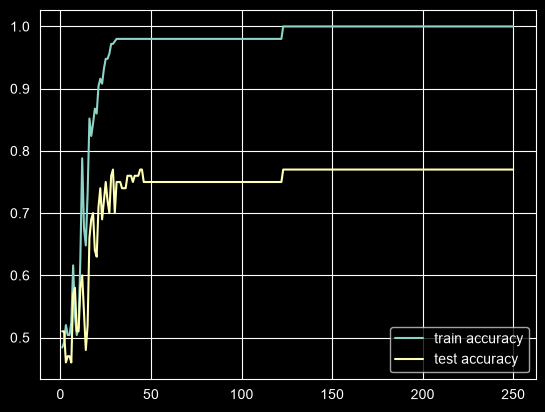

In [115]:
set_seed()


class TransformerBlock(nn.Module):
    def __init__(self,d_model,n_heads):
        super().__init__()
        self.mha = nn.MultiheadAttention(d_model,n_heads,batch_first=True)

        self.norm1 = nn.LayerNorm(d_model)

        self.ffn = nn.Sequential(
            nn.Linear(d_model,4*d_model),
            nn.GELU(),
            nn.Linear(4*d_model,d_model)
        )

        self.norm2 = nn.LayerNorm(d_model)

    def forward(self,x,key_padding_mask=None,attn_mask=None,return_weights=False):
        atten_out,atten_weights = self.mha(
            x,x,x,
            key_padding_mask=key_padding_mask,
            attn_mask=attn_mask,
            need_weights=return_weights,
            average_attn_weights=False,

        )

        after_atten = self.norm1(x+atten_out)

        after_ffn = self.norm2(after_atten+self.ffn(after_atten))

        if return_weights:
            return after_ffn, atten_weights
        return after_ffn


class PositionalEncoder(nn.Module):
    def __init__(self,d_model=32,max_len=MAX_LEN):
        super().__init__()
        positions = torch.arange(max_len,dtype=torch.float32).unsqueeze(1)
        dimentions = torch.arange(0,d_model,2,dtype=torch.float32)

        rates = torch.exp(-math.log(10_000)*dimentions/d_model)

        encoding = torch.zeros(max_len,d_model)
        #=========even===========
        encoding[:,0::2] = torch.sin(positions*rates)
        #===========odd========
        encoding[:,1::2] = torch.cos(positions*rates)

        self.register_buffer("encoding",encoding.unsqueeze(0))

    def forward(self,token_vector):
        length =token_vector.size(1)
        return token_vector+self.encoding[:,:length]


class TinyNewsEncoder(nn.Module):
    def __init__(self, vocab_size, d_model=32, nhead=4, num_layers=2, num_classes=2, max_len=MAX_LEN):
        super().__init__()
        ### START CODE HERE ###
        self.embedding = nn.Embedding(vocab_size,d_model,padding_idx=stoi[PAD])

        self.positional_encoder = PositionalEncoder(d_model,max_len)

        self.blocks = nn.ModuleList(
            [TransformerBlock(d_model, nhead) for _ in range(num_layers)]
        )

        self.classifier = nn.Linear(d_model, num_classes)
        ### END CODE HERE ###

    def forward(self, token_ids):
        ### START CODE HERE ###
        embed_ids =  self.embedding(token_ids)
        h = self.positional_encoder(embed_ids)
        attn_weights = None

        for block in self.blocks:
            h, attn_weights = block(h,return_weights=True)

        valid = token_ids.ne(stoi[PAD]).unsqueeze(-1)
        sentence_vector = (h * valid).sum(dim=1) / valid.sum(dim=1).clamp_min(1)
        logits = self.classifier(sentence_vector)

        return logits,attn_weights
        ### END CODE HERE ###

def make_batch(x,y):
    input_ids = torch.tensor(x,dtype=torch.long)
    labels = torch.tensor(y,dtype=torch.long)
    return input_ids, labels

def encode_documents(texts,max_len=MAX_LEN):
    counter = Counter(freq)
    ids = [
        stoi[token] if counter.get(token,1)>=MIN_FREQ else stoi[UNK]
           for token in texts.split()
    ]

    ids = ids[:max_len]
    ids += [stoi[PAD]]*(max_len-len(ids))
    return ids

def accuracy(model, input_ids, labels):
    model.eval()
    with torch.no_grad():
        logit,_ = model(input_ids)
        pred = logit.argmax(dim=-1)
    return (pred == labels).float().mean().item()


### START CODE HERE ###
# instantiate, pass one batch, print shapes:


X_train_ids = [encode_documents(text) for text in train_texts]
X_test_ids = [encode_documents(text) for text in test_texts]

X_train,y_train = make_batch(X_train_ids,y_train)
X_test,y_test = make_batch(X_test_ids,y_test)
print(f"shape of a document: {X_train[100].shape}")
# token ids, after embedding, after encoder, after classifier

# then train a little and report test accuracy
epochs = 250
loss_fn = nn.CrossEntropyLoss()
transformer = TinyNewsEncoder(len(vocab))
all_train_acc =[]
all_test_acc =[]
optimizer = torch.optim.Adam(transformer.parameters(), lr=0.005)
for epoch in range(epochs):
    transformer.train()
    logit,_ = transformer(X_train)
    loss = loss_fn(logit,y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 20 == 0:
            print(
                f"epoch {epoch:3d} | loss {loss.item():.3f} | "
                f"train {accuracy(transformer, X_train, y_train):.2f} | "
                f"test {accuracy(transformer, X_test, y_test):.2f}"
            )
    all_train_acc.append(accuracy(transformer, X_train, y_train))
    all_test_acc.append(accuracy(transformer, X_test, y_test))
train_acc = accuracy(transformer, X_train, y_train)
test_acc = accuracy(transformer, X_test, y_test)
# pair_pred = predict_senders(transformer, [pair_a, pair_b])
print(
    f"FINAL | train {train_acc:.2f} | test {test_acc:.2f} | "
)
### END CODE HERE ###

# print("encoder test acc:", enc_test_acc)
import matplotlib.pyplot as plt

plt.plot(range(1,epochs+1), all_train_acc, label="train accuracy")
plt.plot(range(1,epochs+1), all_test_acc, label="test accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Experiment without PE

C:\Users\S.Amir Mahdi\AppData\Local\Temp\ipykernel_13628\216507342.py:92: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(y,dtype=torch.long)


shape of a document: torch.Size([64])
epoch   0 | loss 0.698 | train 0.50 | test 0.51
epoch  20 | loss 0.077 | train 0.97 | test 0.74
epoch  40 | loss 0.040 | train 0.98 | test 0.77
epoch  60 | loss 0.038 | train 0.98 | test 0.76
epoch  80 | loss 0.034 | train 0.98 | test 0.71
epoch 100 | loss 0.013 | train 1.00 | test 0.76
epoch 120 | loss 0.013 | train 1.00 | test 0.83
epoch 140 | loss 0.012 | train 1.00 | test 0.82
epoch 160 | loss 0.011 | train 1.00 | test 0.81
epoch 180 | loss 0.010 | train 1.00 | test 0.81
epoch 200 | loss 0.010 | train 1.00 | test 0.81
epoch 220 | loss 0.009 | train 1.00 | test 0.81
epoch 240 | loss 0.008 | train 1.00 | test 0.81
FINAL | train 1.00 | test 0.81 | 


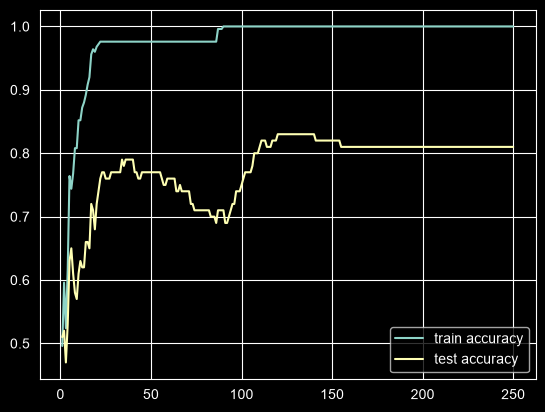

In [116]:
set_seed()


class TransformerBlock(nn.Module):
    def __init__(self,d_model,n_heads):
        super().__init__()
        self.mha = nn.MultiheadAttention(d_model,n_heads,batch_first=True)

        self.norm1 = nn.LayerNorm(d_model)

        self.ffn = nn.Sequential(
            nn.Linear(d_model,4*d_model),
            nn.GELU(),
            nn.Linear(4*d_model,d_model)
        )

        self.norm2 = nn.LayerNorm(d_model)

    def forward(self,x,key_padding_mask=None,attn_mask=None,return_weights=False):
        atten_out,atten_weights = self.mha(
            x,x,x,
            key_padding_mask=key_padding_mask,
            attn_mask=attn_mask,
            need_weights=return_weights,
            average_attn_weights=False,

        )

        after_atten = self.norm1(x+atten_out)

        after_ffn = self.norm2(after_atten+self.ffn(after_atten))

        if return_weights:
            return after_ffn, atten_weights
        return after_ffn


class PositionalEncoder(nn.Module):
    def __init__(self,d_model=32,max_len=MAX_LEN):
        super().__init__()
        positions = torch.arange(max_len,dtype=torch.float32).unsqueeze(1)
        dimentions = torch.arange(0,d_model,2,dtype=torch.float32)

        rates = torch.exp(-math.log(10_000)*dimentions/d_model)

        encoding = torch.zeros(max_len,d_model)
        #=========even===========
        encoding[:,0::2] = torch.sin(positions*rates)
        #===========odd========
        encoding[:,1::2] = torch.cos(positions*rates)

        self.register_buffer("encoding",encoding.unsqueeze(0))

    def forward(self,token_vector):
        length =token_vector.size(1)
        return token_vector+self.encoding[:,:length]


class TinyNewsEncoder(nn.Module):
    def __init__(self, vocab_size, d_model=32, nhead=4, num_layers=2, num_classes=2, max_len=MAX_LEN):
        super().__init__()
        ### START CODE HERE ###
        self.embedding = nn.Embedding(vocab_size,d_model,padding_idx=stoi[PAD])

        self.positional_encoder = PositionalEncoder(d_model,max_len)

        self.blocks = nn.ModuleList(
            [TransformerBlock(d_model, nhead) for _ in range(num_layers)]
        )

        self.classifier = nn.Linear(d_model, num_classes)
        ### END CODE HERE ###

    def forward(self, token_ids):
        ### START CODE HERE ###
        h =  self.embedding(token_ids)
        # h = self.positional_encoder(embed_ids)
        attn_weights = None

        for block in self.blocks:
            h, attn_weights = block(h,return_weights=True)

        valid = token_ids.ne(stoi[PAD]).unsqueeze(-1)
        sentence_vector = (h * valid).sum(dim=1) / valid.sum(dim=1).clamp_min(1)
        logits = self.classifier(sentence_vector)

        return logits,attn_weights
        ### END CODE HERE ###

def make_batch(x,y):
    input_ids = torch.tensor(x,dtype=torch.long)
    labels = torch.tensor(y,dtype=torch.long)
    return input_ids, labels

def encode_documents(texts,max_len=MAX_LEN):
    counter = Counter(freq)
    ids = [
        stoi[token] if counter.get(token,1)>=MIN_FREQ else stoi[UNK]
           for token in texts.split()
    ]

    ids = ids[:max_len]
    ids += [stoi[PAD]]*(max_len-len(ids))
    return ids

def accuracy(model, input_ids, labels):
    model.eval()
    with torch.no_grad():
        logit,_ = model(input_ids)
        pred = logit.argmax(dim=-1)
    return (pred == labels).float().mean().item()


### START CODE HERE ###
# instantiate, pass one batch, print shapes:


X_train_ids = [encode_documents(text) for text in train_texts]
X_test_ids = [encode_documents(text) for text in test_texts]

X_train,y_train = make_batch(X_train_ids,y_train)
X_test,y_test = make_batch(X_test_ids,y_test)
print(f"shape of a document: {X_train[100].shape}")
# token ids, after embedding, after encoder, after classifier

# then train a little and report test accuracy
epochs = 250
loss_fn = nn.CrossEntropyLoss()
transformer = TinyNewsEncoder(len(vocab))
all_train_acc =[]
all_test_acc =[]
optimizer = torch.optim.Adam(transformer.parameters(), lr=0.005)
for epoch in range(epochs):
    transformer.train()
    logit,_ = transformer(X_train)
    loss = loss_fn(logit,y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 20 == 0:
            print(
                f"epoch {epoch:3d} | loss {loss.item():.3f} | "
                f"train {accuracy(transformer, X_train, y_train):.2f} | "
                f"test {accuracy(transformer, X_test, y_test):.2f}"
            )
    all_train_acc.append(accuracy(transformer, X_train, y_train))
    all_test_acc.append(accuracy(transformer, X_test, y_test))
train_acc = accuracy(transformer, X_train, y_train)
test_acc = accuracy(transformer, X_test, y_test)
# pair_pred = predict_senders(transformer, [pair_a, pair_b])
print(
    f"FINAL | train {train_acc:.2f} | test {test_acc:.2f} | "
)
### END CODE HERE ###

# print("encoder test acc:", enc_test_acc)
import matplotlib.pyplot as plt

plt.plot(range(1,epochs+1), all_train_acc, label="train accuracy")
plt.plot(range(1,epochs+1), all_test_acc, label="test accuracy")
plt.legend()
plt.grid(True)
plt.show()

<div dir="rtl">

### توضیح بخش ۱ـ د

- شکل تنسورها: 250 ×64
- چرا اینجا causal mask نگذاشتید؟ چون task  پپیشبینی لیبل داریم ! نه تولید متن که نباید توکن بعدی دیده شود ! همچنین در این تسک برای درک معنای هر سند باید هر توکن به کلمات قبل و بعد خود همزمان نگاه کند علت استفاده نکردن از ماسک causal این است.

</div>


<div dir="rtl">

## بخش ۱ـ ه. مقایسه و جمع‌بندی

جدول را کامل کنید و به سه سؤال PDF جواب دهید.

</div>


<div dir="rtl">

### جدول مقایسه پروژه ۱

| مدل | دقت آزمون | این مدل چه اطلاعاتی می‌بیند؟                                                              |
|---|-----------|-------------------------------------------------------------------------------------------|
| BoW | 88%       | اطلاعات مربوط به فراوانی داده                                                             |
| میانگین embedding | 80%       | روابط همسایگی اما نابینا نسبت به ترتیب                                                    |
| Encoder | 77%       | درک روابط و ترتیب به صورت همزمان که باعث میشود هر توکن جایگاه خود در جمله را نمایندگی کند |

### سؤال‌ها

1. چرا بدون اطلاعات موقعیت، توجه ترتیب «اول / بعدی» را نمی‌فهمد؟
2. LayerNorm روی چه چیزی اعمال می‌شود؟
3. اگر به‌جای Encoder از RNN یک‌لایه استفاده می‌کردید، گلوگاه اصلی چه بود؟

**پاسخ:**

1. بدون اطلاعات PE مکانیزم Attention تنها متوجه ارتباط هر کلید با کوئری میشود و بر این اساس درصد خاصی از هر ولیو را برمیدارد ! این باعث میشود که روابط را بفهمد ولی ترتیب را نه !

2. روی بردار embedding توکن ها

3. گلوگاه RNN این است که هم امکان پردازش موازی ندارد هم پس از چند لایه دچار خطر Vanishing or expliding gradient میشود که علت آن محو شدن گرادیان توکن های اول یا بزرگ شدن بیش از حد خروجی هاست ! به علت تجمیعی بودن

</div>


<div dir="rtl">

# پروژه ۲. قلم نمایشنامه‌نویس: مدل زبانی کوچک

**هدف:** از متن خام، توکن بعدی را یاد بگیرید و بعد از یک پیشوند چند توکن تولید کنید.

**داده:** `Tiny Shakespeare` — فقط حدود ۱۲۰۰۰ تا ۲۰۰۰۰ نویسهٔ اول، نه کل فایل.

</div>


<div dir="rtl">

## بخش ۲ـ الف. متن، نرمال‌سازی و دو نگاه توکنایزری

باید انجام دهید:
- برش کوچک فایل را بخوانید.
- نرمال‌سازی سبک؛ تصمیم‌تان را بعداً توضیح دهید.
- همان دو خط را با `bert-base-uncased` و `gpt2` توکنایز کنید.
- برای مدل خودتان واژه‌نامه بسازید. توصیه: سطح **نویسه**.

</div>


In [117]:
set_seed()

from pathlib import Path
import re
from transformers import AutoTokenizer
SHAKESPEARE_URL = (
    "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
)

data_path = Path('data')
data_path.resolve()

WindowsPath('E:/Maktab-145/HWs/week13/data')

In [118]:
set_seed()

MAX_CHARS = 16000


### START CODE HERE ###
# download or read the file, keep only MAX_CHARS
# light normalization if you want
def normalize(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z0-9\s.,:;!?'\-]", "", text)
    return text


raw_text = None

with open(data_path / "input.txt") as f:
    raw_text= f.read()


clean_text = normalize(raw_text[:MAX_CHARS])

### END CODE HERE ###

print("chars used:", None)
print(clean_text[:400] if clean_text else None)


chars used: None
first citizen:
before we proceed any further, hear me speak.

all:
speak, speak.

first citizen:
you are all resolved rather to die than to famish?

all:
resolved. resolved.

first citizen:
first, you know caius marcius is chief enemy to the people.

all:
we know't, we know't.

first citizen:
let us kill him, and we'll have corn at our own price.
is't a verdict?

all:
no more talking on't; let it 


In [119]:
set_seed()

sample_lines = clean_text[:200]  # two lines from the text

### START CODE HERE ###
def show_tokenize(tokenizer,text,tokenizer_name):
    tokens = tokenizer.tokenize(text)
    token_ids = tokenizer.encode(text)
    decoded = tokenizer.decode(token_ids)
    n_ids = len(token_ids)

    print("=" * 72)
    print("tokenizer:\n", tokenizer_name)
    print("text     :\n", text)
    print("tokens   :\n", tokens)
    print("tokens size   :\n", len(tokens))
    print("ids      :\n", token_ids)
    print("n_ids    :\n", n_ids)
    print("decoded  :\n", decoded)

tokenizer_call = {
    "BERT WordPiece": "bert-base-uncased",
    "GPT-2 BPE": "gpt2"}

tokenizers = {}
for name, model_name in tokenizer_call.items():
    tokenizers[name] = AutoTokenizer.from_pretrained(model_name)
    print("loaded:", name, "vocab size =", tokenizers[name].vocab_size)
# tokenize sample_lines with bert-base-uncased and gpt2
# print tokens, ids, and number of ids for each tokenizer
show_tokenize(tokenizers["BERT WordPiece"],sample_lines,"BERT WordPiece:bert-base-uncased")

show_tokenize(tokenizers["GPT-2 BPE"],sample_lines,"GPT-2 BPE:gpt2")

### END CODE HERE ###


loaded: BERT WordPiece vocab size = 30522
loaded: GPT-2 BPE vocab size = 50257
tokenizer:
 BERT WordPiece:bert-base-uncased
text     :
 first citizen:
before we proceed any further, hear me speak.

all:
speak, speak.

first citizen:
you are all resolved rather to die than to famish?

all:
resolved. resolved.

first citizen:
first, you
tokens   :
 ['first', 'citizen', ':', 'before', 'we', 'proceed', 'any', 'further', ',', 'hear', 'me', 'speak', '.', 'all', ':', 'speak', ',', 'speak', '.', 'first', 'citizen', ':', 'you', 'are', 'all', 'resolved', 'rather', 'to', 'die', 'than', 'to', 'fa', '##mis', '##h', '?', 'all', ':', 'resolved', '.', 'resolved', '.', 'first', 'citizen', ':', 'first', ',', 'you']
tokens size   :
 47
ids      :
 [101, 2034, 6926, 1024, 2077, 2057, 10838, 2151, 2582, 1010, 2963, 2033, 3713, 1012, 2035, 1024, 3713, 1010, 3713, 1012, 2034, 6926, 1024, 2017, 2024, 2035, 10395, 2738, 2000, 3280, 2084, 2000, 6904, 15630, 2232, 1029, 2035, 1024, 10395, 1012, 10395, 1012, 2034

In [120]:
set_seed()

### START CODE HERE ###
# build a character-level vocab from `text`
all_chars = sorted(list(set(sample_lines)))
vocab = ["<PAD>","<UNK>"]
vocab+= all_chars

# stoi / itos / stream of ids
stoi = {token:i for i,token in enumerate(vocab)}
itos = {i:token for i,token in enumerate(vocab)}
stream_ids = [stoi[c] for c in sample_lines]
### END CODE HERE ###

print("char vocab size:", len(vocab))
print("stream length:", len(stream_ids))

char vocab size: 30
stream length: 200


<div dir="rtl">

### توضیح بخش ۲ـ الف

- چه نرمال‌سازی‌ای کردید و چرا؟ lower کردم کل متن رو که کاراکتر های اضافی برای هر لغت ایجاد نشه ، غیر از اون خیلی تهاجمی عمل نکردم چون در همچین متن هایی علائم نگارشی و فاصله ها و تب ها و خطوط جدید معنا دارند
- BERT و GPT-2 روی همان دو خط چه فرقی داشتند؟ بر اساس کارکاتر توکن نکردن ! بر اساس واژه ها و برخی ترکیب ها توکن کردن که باعث میشه واژه نامه طولانی تری داشته باشن ! ولی مفاهیم عمیق تری در توکن ها قرار گرفته اما در نهایت stream_length کمتری داشتند ! چون مثل روش کارکتری ! حرف به حرف انکود نکرده بود
- چرا برای آموزش مدل خودتان واژه‌نامهٔ کوچک ساختید؟ چون سیستم نمیکشه !

</div>


<div dir="rtl">

## بخش ۲ـ ب. ساخت مثال next-token

باید انجام دهید:
- پنجره‌های طول ثابت، مثلاً ۳۲ یا ۶۴
- ورودی: همه به‌جز آخری ؛ هدف: همه به‌جز اولی
- یک مثال را از ID به متن برگردانید

</div>


In [121]:
set_seed()

SEQ_LEN = 64

all_chars = sorted(list(set(clean_text)))
vocab = ["<PAD>","<UNK>"]
vocab+= all_chars

stoi = {token:i for i,token in enumerate(vocab)}
itos = {i:token for i,token in enumerate(vocab)}
stream_ids = [stoi[c] for c in sample_lines]
token_ids = [stoi[c] for c in clean_text]
### START CODE HERE ###
windows = []
for start in range(0,len(token_ids)-SEQ_LEN,1):
    window = token_ids[start:start+SEQ_LEN+1]
    windows.append(window)

windows = torch.tensor(windows,dtype=torch.long)
x_lm = windows[:,:-1]
# t + 1
y_lm = windows[:,1:]

# x_lm = None  # [num_windows, SEQ_LEN]
# y_lm = None  # [num_windows, SEQ_LEN]
### END CODE HERE ###

print("x_lm:", x_lm.shape)
print("y_lm:", y_lm.shape)

example_in = "".join([itos[idx.item()] for idx in x_lm[0]])
example_target = "".join([itos[idx.item()] for idx in y_lm[0]])
print("example input :\n", repr(example_in))
print("example target:\n", repr(example_target))


x_lm: torch.Size([15936, 64])
y_lm: torch.Size([15936, 64])
example input :
 'first citizen:\nbefore we proceed any further, hear me speak.\n\nal'
example target:
 'irst citizen:\nbefore we proceed any further, hear me speak.\n\nall'


<div dir="rtl">

### توضیح بخش ۲ـ ب

- این کار چرا self-supervised است؟ چون در این روش لیبل مشخصی از پیش وجود ندارد ! مدل باید بیاموزد بر اساس توالی موجود توکن بعدی را تولید کند پس خودش باید تشخیص دهد توکن درست چیست !
- در مثال شما، مدل باید بعد از توکن اولِ ورودی چه چیزی را پیش‌بینی کند؟توکن بعدی را

</div>


<div dir="rtl">

## بخش ۲ـ ج. مدل decoder-style و ماسک علّی

باید انجام دهید:
- embedding توکن + embedding موقعیت + Transformer + لایه به اندازهٔ واژه‌نامه
- **ماسک علّی**
- چاپ ماسک طول ۸
- عبور یک batch و چاپ شکل logits: `[batch, length, vocab]`

</div>


In [122]:
set_seed()

class TinyCharLM(nn.Module):
    def __init__(self, vocab_size, d_model=32, nhead=4, num_layers=2, max_len=128):
        super().__init__()
        ### START CODE HERE ###
        self.embedding = nn.Embedding(vocab_size, d_model)

        self.position_embedding = nn.Embedding(max_len, d_model)

        layer = nn.TransformerDecoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=4*d_model,
            batch_first=True,
            norm_first=True
        )

        self.transformer = nn.TransformerDecoder(layer, num_layers=num_layers)
        ### END CODE HERE ###

        self.lm_head = nn.Linear(d_model, vocab_size)
    def forward(self, token_ids):
        ### START CODE HERE ###
        batch,seq_len = token_ids.shape
        pos = torch.arange(seq_len,device=token_ids.device)

        x = self.embedding(token_ids) + self.position_embedding(pos)
        causal_mask = torch.triu(torch.ones(seq_len,seq_len,device=token_ids.device)==1,diagonal=1)

        out = self.transformer(tgt=x,memory=x,tgt_mask=causal_mask)


        # build causal mask; True means blocked
        return self.lm_head(out),causal_mask
        ### END CODE HERE ###


### START CODE HERE ###
transformer = TinyCharLM(len(vocab))

# X_test, y_test = make_batch(test_texts,y_test)

output, causal = transformer(x_lm[:10])
# print an 8x8 causal mask
print(f"causal: {causal.shape}")
print(f"output: {output.shape}")
print(f"token_ids: {x_lm.shape}")
# pass a small batch and print logits shape
### END CODE HERE ###


causal: torch.Size([64, 64])
output: torch.Size([10, 64, 38])
token_ids: torch.Size([15936, 64])


<div dir="rtl">

### توضیح بخش ۲ـج

- `True` در ماسک یعنی چه؟ توکن هایی که نباید ببیند ( توکن های آینده )
- Encoder را انتخاب کردید یا Decoder؟ چرا این انتخاب decoder-style است؟ دیکودر با اتنشن کردن به سیکوانس انکود شده سعی در تولید توکن بعدی دارید این تسک هم همین بود برای همین دیکودر انتخاب کردم
- Decoder نسبت به Encoder چه زیرماژول اضافه‌ای دارد؟ ماژول دیکودر یا ترنسفورمر لیر

</div>


l<div dir="rtl">

## بخش ۲ـ د. آموزش کوتاه و تولید متن

باید انجام دهید:
- چند ده step با CrossEntropyLoss
- تابع تولید: پیشوند → توکن بعدی → اضافه کردن → تکرار
- شروع از `ROMEO:` یا `First Citizen:`
- حدود ۸۰ تا ۱۲۰ نویسه چاپ کنید

</div>


In [123]:
set_seed()

### START CODE HERE ###
# train a little; print loss every few steps

torch.manual_seed(42)
torch.cuda.manual_seed(42)
torch.backends.deterministic = True
torch.backends.benchmark = False

epochs = 250
loss_fn = nn.CrossEntropyLoss()
transformer = TinyCharLM(len(vocab))
optimizer = torch.optim.Adam(transformer.parameters(),lr=0.001)

batch_size = 64
all_loss = []
for epoch in range(1,epochs+1):
    transformer.train()

    idx = torch.randint(0, x_lm.size(0), (batch_size,))
    logits, _ = transformer(x_lm[idx])

    loss = loss_fn(
        logits.reshape(-1, len(vocab)),
        y_lm[idx].reshape(-1)
    )

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    all_loss.append(loss.item())
    if epoch % 10 == 0:
        print(f"step {epoch }: loss={loss.item():.4f}")

### END CODE HERE ###


step 10: loss=3.5199
step 20: loss=3.2143
step 30: loss=3.0171
step 40: loss=2.9265
step 50: loss=2.8533
step 60: loss=2.8250
step 70: loss=2.7477
step 80: loss=2.7064
step 90: loss=2.6835
step 100: loss=2.6420
step 110: loss=2.6548
step 120: loss=2.6197
step 130: loss=2.6116
step 140: loss=2.6004
step 150: loss=2.5366
step 160: loss=2.5412
step 170: loss=2.5434
step 180: loss=2.5150
step 190: loss=2.4838
step 200: loss=2.4719
step 210: loss=2.4779
step 220: loss=2.4657
step 230: loss=2.4366
step 240: loss=2.4371
step 250: loss=2.4663


In [124]:
set_seed()

def generate(model, prefix: str, max_new_tokens: int = 120) -> str:
    ### START CODE HERE ###
    model.eval()
    device = next(model.parameters()).device
    ids = [stoi[c] for c in prefix]

    token_ids = torch.tensor([ids], dtype=torch.long, device=device)

    with torch.no_grad():
        for _ in range(max_new_tokens):
            # maximum length == model maximum length (-model.position_embedding.num_embeddings)
            context = token_ids[:, -model.position_embedding.num_embeddings:]

            logit,_ = model(context)


            # pred next token from last position
            next_logit = logit[:,-1,:]
            next_id = torch.argmax(next_logit, dim=-1,keepdim=True)

            token_ids = torch.cat([token_ids, next_id], dim=1)

    return "".join(itos[i] for i in token_ids[0].tolist())

    return prefix
    ### END CODE HERE ###


print(generate(transformer, "first citizen:"))


first citizen:
win:






















































iz








ititin:

ti
n














tin:








citillll


<div dir="rtl">

### توضیح بخش ۲ـ د

- loss چقدر کم شد؟ شروع لاس step 10: loss=3.5199 پایانش step 250: loss=2.4663 با ریت یادگیری 0.001
- متن تولیدی چه الگویی را تا حدی یاد گرفته و چه چیزی را بلد نیست؟ در گیر حلقه های تکرار شده ! به نظر من علت این قضیه ناشی از کارکتر لول بودن توکنایز بوده ! به جای دادن ترکیب های معنا دار به مدل لغت دادیم ! مدل برای تولید هر کلمه باید به سختی لغت به لغت کلمه رو بسازه و یه خطای کوچیک مسیر رو نابود میکنه !!!

</div>


<div dir="rtl">

## بخش ۲ـ ه. یک آزمایش کوچک و جمع‌بندی

فقط **یکی** از سه آزمایش PDF را انجام دهید. بعد به دو سؤال آخر جواب دهید.

</div>


# without positional encoding  --> Cell 116 final score 81% for test

In [126]:
### START CODE HERE ###
# optional: train briefly without causal mask
# or without positional embedding
# then write what you observed in the markdown cell below
### END CODE HERE ###


<div dir="rtl">

### توضیح بخش ۲ـ ه

کدام آزمایش را انتخاب کردید و چه دیدید؟

**سؤال‌ها**

1. چرا پروژهٔ ۱ به ماسک علّی نیاز نداشت و پروژهٔ ۲ نیاز داشت؟
2. فرق pretraining خودنظارتی این پروژه با fine-tune روی برچسب موضوع خبر چیست؟

**پاسخ:**

1.چون پروژه اول قرار نبود توکن بعدی رو پیش بینی کنه ! برای کلاس بندی موضوع خبر باید به کل موارد توجه میکرد ! ولی پروژه دوم باید مثل شکسپیر متن تولید میکرد و این کار رو با نگاه کردن به توکن های گذشته میکنه برای همین نباید توکن های آینده رو ببینه
2. در پروژه 1 یکسری برچسب داشتیم که سعی میکردیم مدل رو برای رسیدن به پیش بینی درست این برچسب ها آموزش بدیم
در پروژه 2 لیبل مشخص نداشتیم و self-supervised  بود و مدل باید یادمیگرفت next-token  ها رو یا همون y_lm رو به درستی پیش بینی کنه

</div>


<div dir="rtl">

# چک‌لیست قبل از ارسال

- [ ] پروژهٔ ۱ روی حداکثر ۲۵۰+۱۰۰ سند از دو کلاس خواسته‌شده اجرا شده است.
- [ ] BoW، میانگین embedding و Encoder گزارش شده‌اند.
- [ ] دو سند اشتباه BoW و یک جفت جملهٔ دلخواه آمده است.
- [ ] چند جفت skip-gram ساخته شده است.
- [ ] پروژهٔ ۲ روی برش کوچک Tiny Shakespeare است.
- [ ] BERT و GPT-2 فقط برای مشاهدهٔ دو خط استفاده شده‌اند.
- [ ] یک مثال ورودی/هدف شیفت‌شده چاپ شده است.
- [ ] ماسک علّی چاپ شده و یک متن کوتاه تولید شده است.
- [ ] همهٔ سلول‌های «توضیح این بخش» پر شده‌اند.

</div>
